<a href="https://colab.research.google.com/github/Dungmeww/ThucHanh_DeepLearning/blob/Buoi4/CNN_bai2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Đang tải dữ liệu CIFAR-10...
Tải dữ liệu thành công!
Kích thước tập Train: (50000, 32, 32, 3)
Kích thước tập Test: (10000, 32, 32, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)


--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ---
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 85ms/step - accuracy: 0.4230 - loss: 1.5770 - val_accuracy: 0.4924 - val_loss: 1.4136
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 84ms/step - accuracy: 0.5592 - loss: 1.2374 - val_accuracy: 0.5860 - val_loss: 1.1819
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 84ms/step - accuracy: 0.6108 - loss: 1.1006 - val_accuracy: 0.6294 - val_loss: 1.0639
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.6480 - loss: 1.0017 - val_accuracy: 0.6445 - val_loss: 1.0134
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.6747 - loss: 0.9264 - val_accuracy: 0.6660 - val_loss: 0.9677
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.6947 - loss: 0.8735 - val_accuracy: 0.6839 - val_loss: 0.9062
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 85ms/step - accuracy: 0.7142 - loss: 0.8200 - val_accuracy: 0.6877 - val_loss: 0.9044
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 82ms/step 

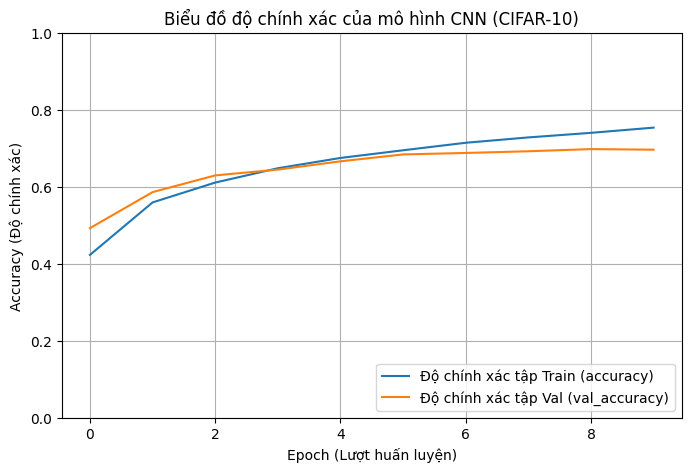

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# 1. Tải bộ dữ liệu CIFAR-10 từ hệ thống của Keras
# Bộ dữ liệu này gồm các ảnh màu 32x32 với 10 lớp đối tượng khác nhau
print("Đang tải dữ liệu CIFAR-10...")
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Chuẩn hóa giá trị các điểm ảnh (pixels) về đoạn từ 0 đến 1
X_train, X_test = X_train / 255.0, X_test / 255.0

# Danh sách tên các nhãn tương ứng
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Tải dữ liệu thành công!")
print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

# 2. Khởi tạo cấu trúc mạng CNN
model = models.Sequential()

# Tập hợp các tầng Tích chập (Convolutional) và Trích xuất (Pooling)
# Do ảnh CIFAR-10 là ảnh màu, input_shape sẽ là (32, 32, 3)
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Tầng phẳng hóa (Flatten) và các tầng Kết nối đầy đủ (Dense / Fully Connected)
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10)) # 10 đầu ra tương ứng với 10 lớp phân loại

# Hiển thị bảng tóm tắt cấu trúc mạng
model.summary()

# 3. Cấu hình các tham số huấn luyện (Compile)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 4. Tiến hành huấn luyện mô hình (Train)
# Trên Colab, bạn có thể chạy 10 epochs trong khoảng 1-2 phút
print("\n--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ---")
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_test, y_test),
                    batch_size=64)

# 5. Đánh giá độ chính xác trên tập Test độc lập
print("\n--- ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST ---")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nĐộ chính xác trên tập Test (Test accuracy): {test_acc * 100:.2f}%')

# 6. Vẽ biểu đồ hiển thị độ chính xác (Accuracy) qua từng Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Độ chính xác tập Train (accuracy)')
plt.plot(history.history['val_accuracy'], label = 'Độ chính xác tập Val (val_accuracy)')
plt.title('Biểu đồ độ chính xác của mô hình CNN (CIFAR-10)')
plt.xlabel('Epoch (Lượt huấn luyện)')
plt.ylabel('Accuracy (Độ chính xác)')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Vui lòng tải lên một hình ảnh để kiểm tra:


Saving United_Airlines_Boeing_777-200_Meulemans.jpg to United_Airlines_Boeing_777-200_Meulemans (1).jpg

Đã tải lên ảnh: United_Airlines_Boeing_777-200_Meulemans (1).jpg


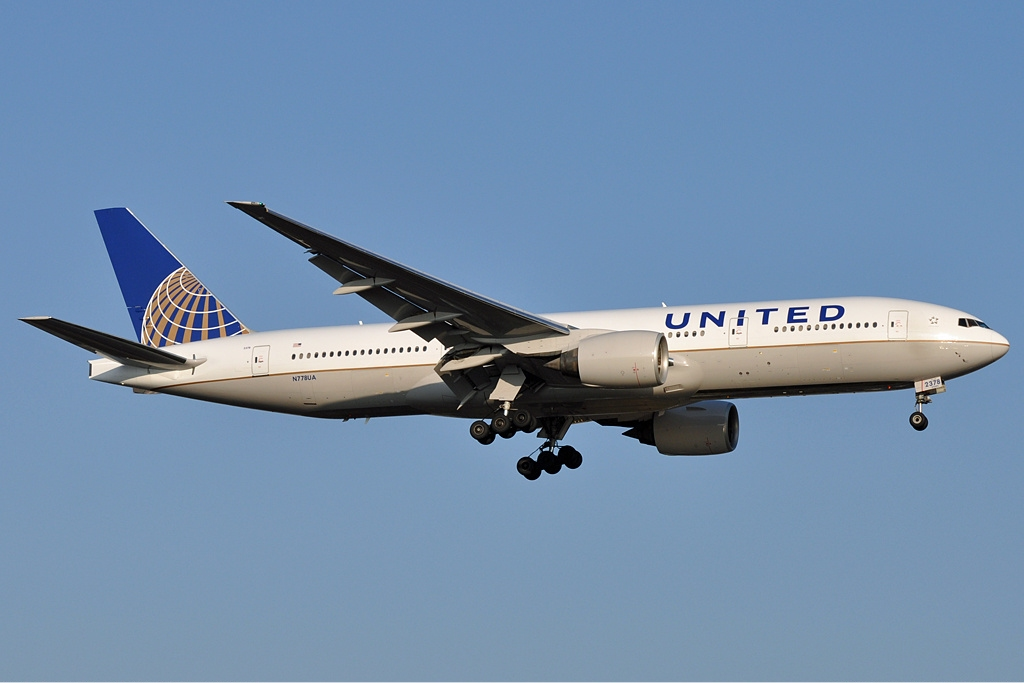

In [ ]:
from IPython.display import display, Image as DisplayImage
from google.colab import files
from PIL import Image
import numpy as np

print("Vui lòng tải lên một hình ảnh để kiểm tra:")
uploaded = files.upload()

for fn in uploaded.keys():
    path = '/content/' + fn
    pil_img = Image.open(path).resize((32, 32)) # Use PIL.Image.open
    img_array = np.array(pil_img) / 255.0 # Chuẩn hóa ảnh
    img_array = np.expand_dims(img_array, axis=0) # Thêm chiều batch

    print(f"\nĐã tải lên ảnh: {fn}")
    display(DisplayImage(path, width=150, height=150)) # Use aliased IPython.display.Image


In [ ]:
if 'img_array' in locals():
    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence = tf.nn.softmax(predictions[0])[predicted_class_index].numpy()

    print(f"\nPhân loại của mô hình: {predicted_class_name}")
    print(f"Độ tin cậy: {confidence:.2f}")
else:
    print("Chưa có ảnh nào được tải lên để dự đoán.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step

Phân loại của mô hình: airplane
Độ tin cậy: 1.00
